<a href="https://colab.research.google.com/github/iffathsaleem/FYP_Project/blob/main/PaySim_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1: Setup

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import chi2_contingency
import gc
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Part 2: Define File Path

In [ ]:
BASE_PATH = Path("/content/drive/MyDrive/FYP/Dataset/PaySim Synthetic Financial Transactions")

DATA_PATH = BASE_PATH / "PS_20174392719_1491204439457_log.csv"

print(DATA_PATH)

/content/drive/MyDrive/FYP/Dataset/PaySim Synthetic Financial Transactions/PS_20174392719_1491204439457_log.csv


## Part 3: Load Dataset Efficiently

In [ ]:
dtype_map = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "nameOrig": "string",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "nameDest": "string",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "uint8",
    "isFlaggedFraud": "uint8"
}

paysim = pd.read_csv(DATA_PATH, dtype=dtype_map)

print("PaySim dataset loaded successfully!")
print("Shape:", paysim.shape)

PaySim dataset loaded successfully!
Shape: (6362620, 11)


## Part 4: Dataset Understanding

In [ ]:
print("\n" + "="*80)
print("PART 1: DATASET UNDERSTANDING")
print("="*80)

print(f"\nRows: {paysim.shape[0]:,}")
print(f"Columns: {paysim.shape[1]}")

display(paysim.head())


PART 1: DATASET UNDERSTANDING

Rows: 6,362,620
Columns: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0


### 4.1 Variable Meanings

In [ ]:
variable_description = pd.DataFrame({
    "Variable": [
        "step",
        "type",
        "amount",
        "nameOrig",
        "oldbalanceOrg",
        "newbalanceOrig",
        "nameDest",
        "oldbalanceDest",
        "newbalanceDest",
        "isFraud",
        "isFlaggedFraud"
    ],
    "Meaning": [
        "Simulation time step",
        "Transaction type",
        "Transaction amount",
        "Origin account/customer",
        "Origin balance before transaction",
        "Origin balance after transaction",
        "Destination account/customer",
        "Destination balance before transaction",
        "Destination balance after transaction",
        "Actual fraud label",
        "Existing rule/system fraud flag"
    ],
    "Fraud Relevance": [
        "Allows temporal fraud analysis",
        "Different transaction types may have different fraud exposure",
        "Fraud may behave differently across transaction values",
        "Allows origin-account behaviour analysis",
        "Shows available funds before transaction",
        "Shows financial effect on sender",
        "Allows destination-account behaviour analysis",
        "Shows receiver balance before transaction",
        "Shows financial effect on receiver",
        "Target variable for fraud detection",
        "Can be evaluated as a rule-based fraud baseline"
    ]
})

display(variable_description)

,Variable,Meaning,Fraud Relevance
0,step,Simulation time step,Allows temporal fraud analysis
1,type,Transaction type,Different transaction types may have different...
2,amount,Transaction amount,Fraud may behave differently across transactio...
3,nameOrig,Origin account/customer,Allows origin-account behaviour analysis
4,oldbalanceOrg,Origin balance before transaction,Shows available funds before transaction
5,newbalanceOrig,Origin balance after transaction,Shows financial effect on sender
6,nameDest,Destination account/customer,Allows destination-account behaviour analysis
7,oldbalanceDest,Destination balance before transaction,Shows receiver balance before transaction
8,newbalanceDest,Destination balance after transaction,Shows financial effect on receiver
9,isFraud,Actual fraud label,Target variable for fraud detection


## Part 5: Data Types

In [ ]:
print("\n" + "="*80)
print("PART 2: VARIABLE TYPES")
print("="*80)

display(paysim.dtypes.rename("Data Type").to_frame())


PART 2: VARIABLE TYPES


,Data Type
step,int16
type,category
amount,float32
nameOrig,string[python]
oldbalanceOrg,float32
newbalanceOrig,float32
nameDest,string[python]
oldbalanceDest,float32
newbalanceDest,float32
isFraud,uint8


In [ ]:
print("\nData type counts:")
display(paysim.dtypes.value_counts().rename("Number of Variables"))


Data type counts:


,Number of Variables
float32,5
uint8,2
string[python],2
int16,1
category,1


## Part 6: Unique Values / Cardinality

In [ ]:
cardinality = pd.DataFrame({
    "Variable": paysim.columns,
    "Unique Values": [paysim[col].nunique(dropna=False) for col in paysim.columns]
})
cardinality = cardinality.sort_values("Unique Values", ascending=False)

display(cardinality)

,Variable,Unique Values
3,nameOrig,6353307
2,amount,5236933
7,oldbalanceDest,3532215
8,newbalanceDest,3474507
6,nameDest,2722362
5,newbalanceOrig,2663280
4,oldbalanceOrg,1834373
0,step,743
1,type,5
9,isFraud,2


## Part 7: Duplicate Analysis

In [ ]:
print("\n" + "="*80)
print("PART 3: DUPLICATE ANALYSIS")
print("="*80)

duplicate_rows = paysim.duplicated().sum()
print(f"Duplicate complete rows: {duplicate_rows:,}")


PART 3: DUPLICATE ANALYSIS
Duplicate complete rows: 0


In [ ]:
print(f"Unique origin accounts: {paysim['nameOrig'].nunique():,}")
print(f"Unique destination accounts: {paysim['nameDest'].nunique():,}")

Unique origin accounts: 6,353,307
Unique destination accounts: 2,722,362


## Part 8: Missing Values

In [ ]:
print("\n" + "="*80)
print("PART 4: MISSING VALUE ANALYSIS")
print("="*80)

missing = pd.DataFrame({
    "Missing Count": paysim.isna().sum(),
    "Missing %": paysim.isna().mean() * 100
})

display(missing.sort_values("Missing %", ascending=False))


PART 4: MISSING VALUE ANALYSIS


,Missing Count,Missing %
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


## Part 9: Numeric Summary

In [ ]:
numeric_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

summary = paysim[numeric_cols].describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]).T

display(summary)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,9.000000,16.000000,35.000000,156.000000,239.000000,3.350000e+02,399.000,4.900000e+02,6.810000e+02,743.0
amount,6362620.0,1.798619e+05,5.991358e+05,0.0,449.467593,2224.099597,4501.299805,13389.570312,74871.937500,2.087215e+05,365423.300,5.186342e+05,1.615980e+06,92445520.0
oldbalanceOrg,6362620.0,8.338834e+05,2.831753e+06,0.0,0.000000,0.000000,0.000000,0.000000,14208.000000,1.073152e+05,1822508.275,5.823702e+06,1.602726e+07,59585040.0
newbalanceOrig,6362620.0,8.551137e+05,2.862818e+06,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.442584e+05,1970344.750,5.980262e+06,1.617616e+07,49585040.0
oldbalanceDest,6362620.0,1.100702e+06,3.369338e+06,0.0,0.000000,0.000000,0.000000,0.000000,132705.664062,9.430367e+05,2914266.600,5.147230e+06,1.237182e+07,356015904.0
newbalanceDest,6362620.0,1.224997e+06,3.629806e+06,0.0,0.000000,0.000000,0.000000,0.000000,214661.445312,1.111909e+06,3194869.650,5.515716e+06,1.313787e+07,356179264.0


## Part 10: Fraud Target Analysis

In [ ]:
print("\n" + "="*80)
print("PART 5: FRAUD TARGET ANALYSIS")
print("="*80)

fraud_counts = paysim["isFraud"].value_counts()
fraud_percent = paysim["isFraud"].value_counts(normalize=True) * 100

print(f"Legitimate transactions: {fraud_counts.get(0,0):,} ({fraud_percent.get(0,0):.4f}%)")
print(f"Fraudulent transactions: {fraud_counts.get(1,0):,} ({fraud_percent.get(1,0):.4f}%)")


PART 5: FRAUD TARGET ANALYSIS
Legitimate transactions: 6,354,407 (99.8709%)
Fraudulent transactions: 8,213 (0.1291%)


### 10.1 Plot Fraud Distribution

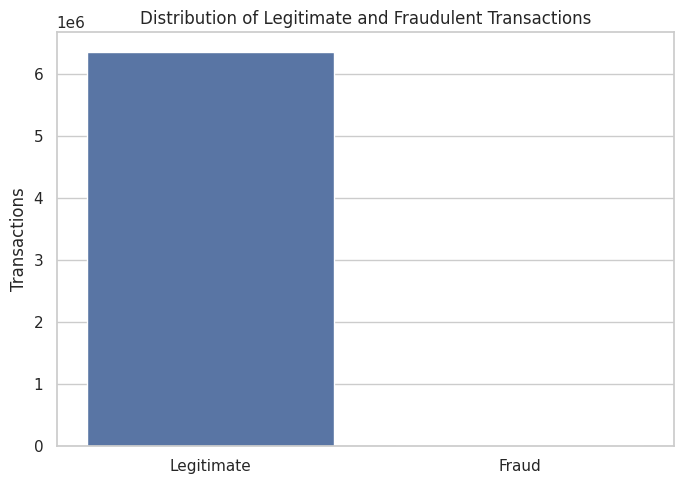

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=paysim, x="isFraud")
plt.xticks([0,1], ["Legitimate", "Fraud"])
plt.xlabel("")
plt.ylabel("Transactions")
plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.tight_layout()
plt.show()

### 10.2 Class Imbalance Ratio

In [ ]:
legitimate_count = (paysim["isFraud"] == 0).sum()
fraud_count = (paysim["isFraud"] == 1).sum()
imbalance_ratio = legitimate_count / fraud_count

print(f"Class imbalance ratio: {imbalance_ratio:.2f}:1")
print("This justifies using Precision, Recall, F1, ROC-AUC, PR-AUC, and FPR rather than accuracy.")

Class imbalance ratio: 773.70:1
This justifies using Precision, Recall, F1, ROC-AUC, PR-AUC, and FPR rather than accuracy.


## Part 11: Existing Fraud Flag Analysis

In [ ]:
print("\n" + "="*80)
print("PART 6: EXISTING FRAUD FLAG ANALYSIS")
print("="*80)

flag_summary = paysim["isFlaggedFraud"].value_counts(dropna=False)
display(flag_summary)


PART 6: EXISTING FRAUD FLAG ANALYSIS


,count
isFlaggedFraud,
0,6362604
1,16


In [ ]:
display(paysim["isFlaggedFraud"].value_counts(normalize=True) * 100)

,proportion
isFlaggedFraud,
0,99.999749
1,0.000251


## Part 12: Compare Existing Flag Against Actual Fraud

In [ ]:
cm = confusion_matrix(paysim["isFraud"], paysim["isFlaggedFraud"])
tn, fp, fn, tp = cm.ravel()

print("Existing Fraud Flag Performance")
print("="*50)
print(f"True Positives:  {tp:,}")
print(f"False Positives: {fp:,}")
print(f"True Negatives:  {tn:,}")
print(f"False Negatives: {fn:,}")

Existing Fraud Flag Performance
True Positives:  16
False Positives: 0
True Negatives:  6,354,407
False Negatives: 8,197


### 12.1 Precision, Recall and F1

In [ ]:
precision = precision_score(paysim["isFraud"], paysim["isFlaggedFraud"], zero_division=0)
recall = recall_score(paysim["isFraud"], paysim["isFlaggedFraud"], zero_division=0)
f1 = f1_score(paysim["isFraud"], paysim["isFlaggedFraud"], zero_division=0)
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"False Positive Rate: {false_positive_rate:.6f}")

Precision: 1.0000
Recall: 0.0019
F1 Score: 0.0039
False Positive Rate: 0.000000


## Part 13: Transaction Type Distribution

In [ ]:
print("\n" + "="*80)
print("PART 7: TRANSACTION TYPE ANALYSIS")
print("="*80)

type_distribution = paysim["type"].value_counts()
display(type_distribution)


PART 7: TRANSACTION TYPE ANALYSIS


,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


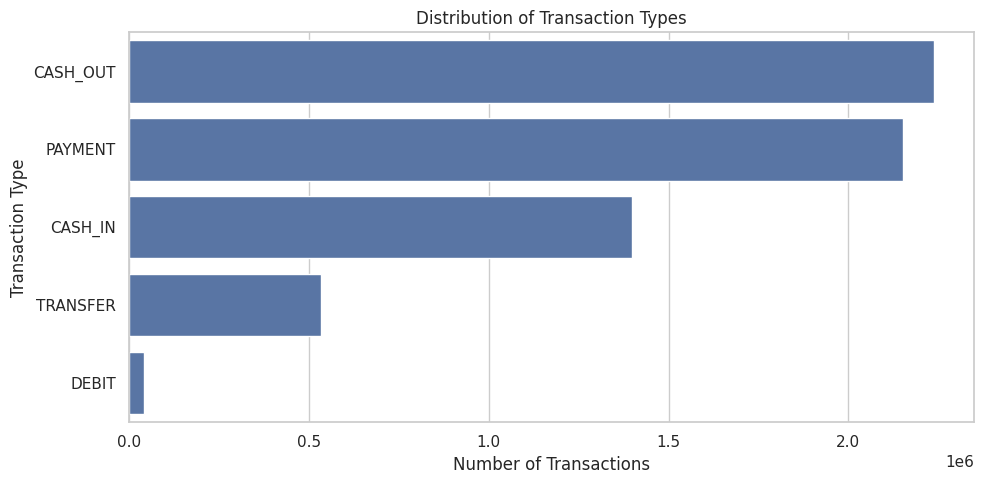

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data=paysim, y="type", order=paysim["type"].value_counts().index)
plt.title("Distribution of Transaction Types")
plt.xlabel("Number of Transactions")
plt.ylabel("Transaction Type")
plt.tight_layout()
plt.show()

## Part 14: Fraud Rate by Transaction Type

In [ ]:
fraud_by_type = paysim.groupby("type", observed=False)["isFraud"].agg(
    Transactions="size",
    Fraud_Count="sum",
    Fraud_Rate="mean"
)
fraud_by_type["Fraud_Rate"] *= 100
fraud_by_type = fraud_by_type.sort_values("Fraud_Rate", ascending=False)

display(fraud_by_type)

,Transactions,Fraud_Count,Fraud_Rate
type,,,
TRANSFER,532909,4097,0.768799
CASH_OUT,2237500,4116,0.183955
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


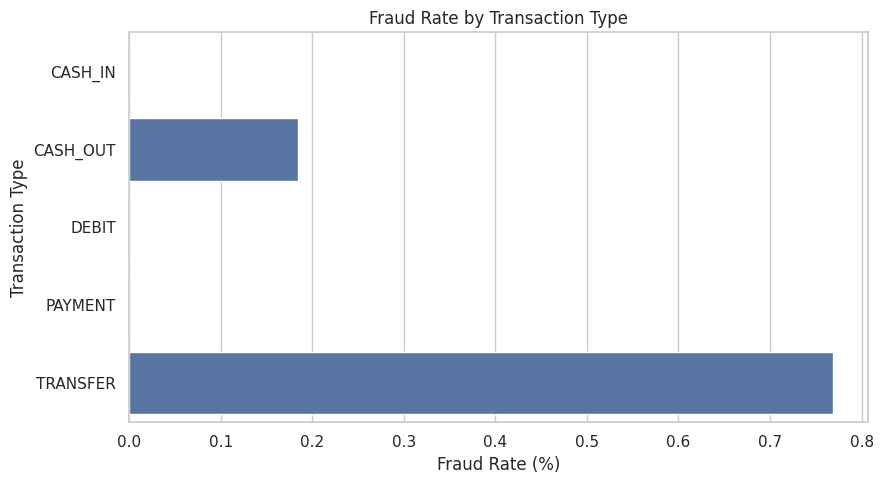

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(data=fraud_by_type.reset_index(), x="Fraud_Rate", y="type")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Transaction Type")
plt.title("Fraud Rate by Transaction Type")
plt.tight_layout()
plt.show()

## Part 15: Fraud Composition by Transaction Type

In [ ]:
fraud_only = paysim[paysim["isFraud"] == 1]
fraud_type_distribution = fraud_only["type"].value_counts(normalize=True) * 100

display(fraud_type_distribution)

,proportion
type,
CASH_OUT,50.11567
TRANSFER,49.88433
CASH_IN,0.00000
DEBIT,0.00000
PAYMENT,0.00000


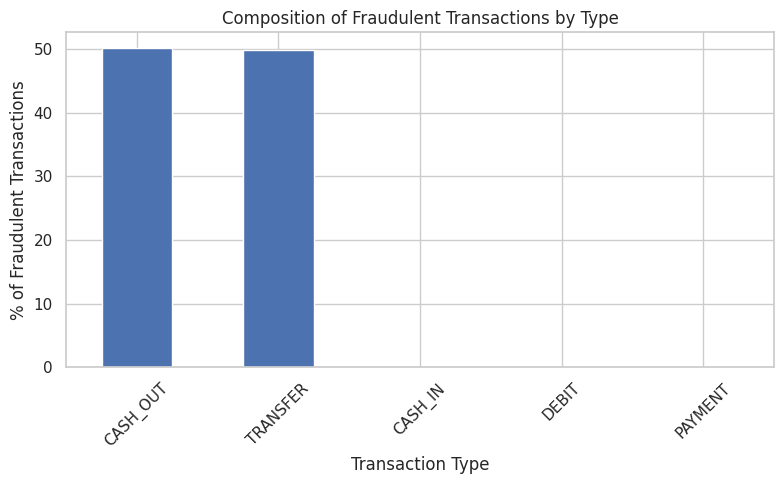

In [ ]:
plt.figure(figsize=(8,5))
fraud_type_distribution.plot(kind="bar")
plt.title("Composition of Fraudulent Transactions by Type")
plt.ylabel("% of Fraudulent Transactions")
plt.xlabel("Transaction Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part 16: Transaction Amount EDA

In [ ]:
print("\n" + "="*80)
print("PART 8: TRANSACTION AMOUNT ANALYSIS")
print("="*80)

display(paysim.groupby("isFraud")["amount"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]))


PART 8: TRANSACTION AMOUNT ANALYSIS


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
isFraud,,,,,,,,,,,,
0,6354407.0,1.781970e+05,591525.00,0.01,449.23999,2221.982983,13368.395020,74684.71875,2.083648e+05,5.156104e+05,1.586064e+06,92445520.0
1,8213.0,1.467967e+06,2404254.25,0.00,1842.00000,17484.289062,127091.328125,441423.43750,1.517772e+06,8.006429e+06,1.000000e+07,10000000.0


## Part 17: Log Transaction Amount

In [ ]:
paysim["log_amount"] = np.log1p(paysim["amount"])

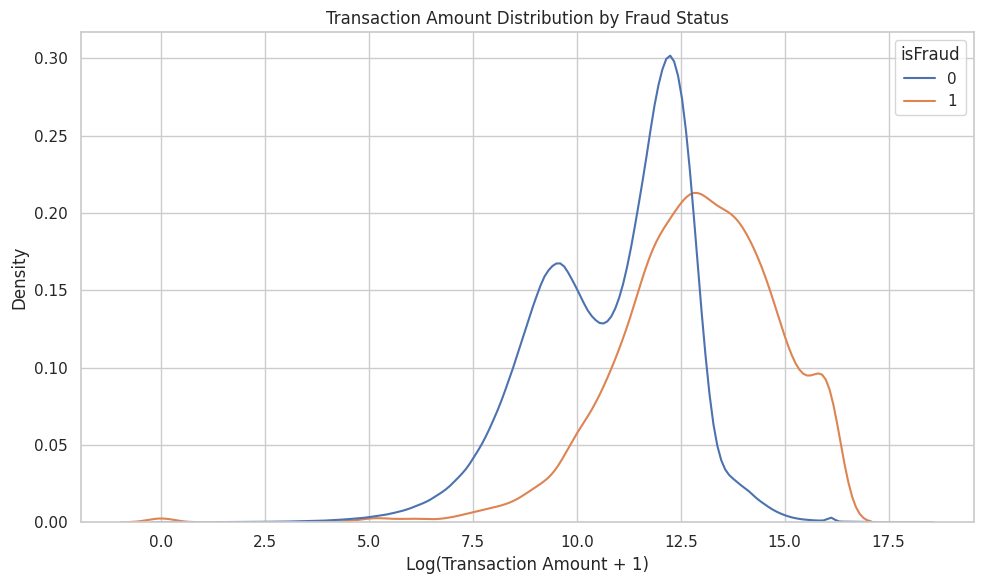

In [ ]:
plt.figure(figsize=(10,6))

sns.kdeplot(data=paysim, x="log_amount", hue="isFraud", common_norm=False)
plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("Log(Transaction Amount + 1)")
plt.tight_layout()
plt.show()

## Part 18: Transaction Amount Quantiles

In [ ]:
paysim["AMOUNT_DECILE"] = pd.qcut(paysim["amount"], q=10, duplicates="drop")

In [ ]:
amount_risk = paysim.groupby("AMOUNT_DECILE", observed=False)["isFraud"].agg(
    Transactions="size",
    Fraud_Count="sum",
    Fraud_Rate="mean"
)
amount_risk["Fraud_Rate"] *= 100

display(amount_risk)

,Transactions,Fraud_Count,Fraud_Rate
AMOUNT_DECILE,,,
"(-0.001, 4501.3]",636263,148,0.023261
"(4501.3, 9866.158]",636261,128,0.020118
"(9866.158, 18092.027]",636262,148,0.023261
"(18092.027, 36371.351]",636262,365,0.057366
"(36371.351, 74871.938]",636262,617,0.096973
"(74871.938, 122563.783]",636262,592,0.093043
"(122563.783, 176801.917]",636262,581,0.091315
"(176801.917, 246611.216]",636262,503,0.079055
"(246611.216, 365423.3]",636262,719,0.113004


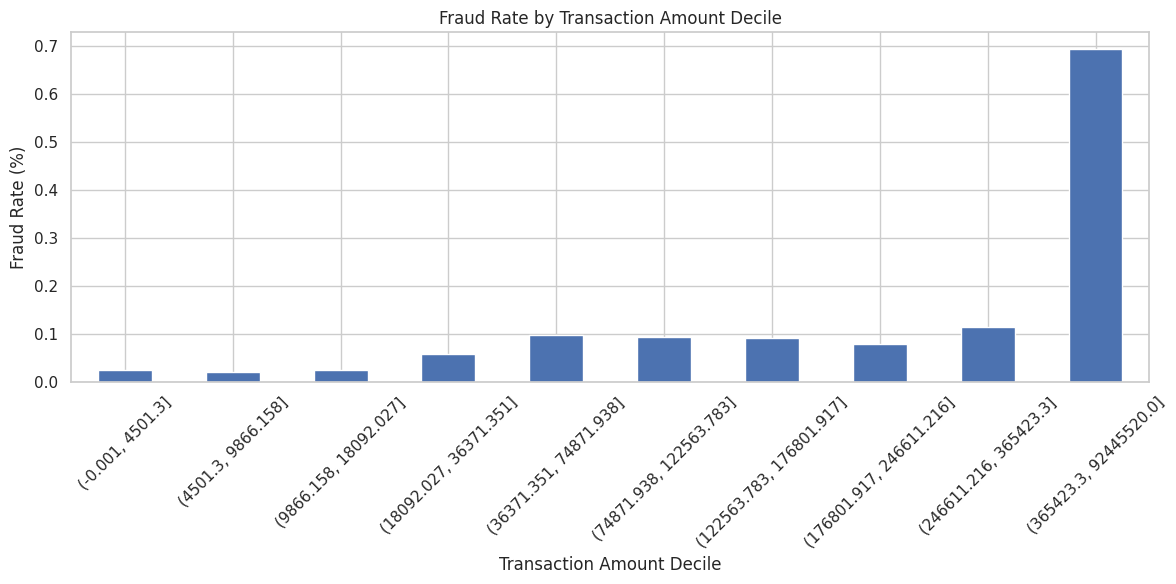

In [ ]:
plt.figure(figsize=(12,6))
amount_risk["Fraud_Rate"].plot(kind="bar")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Transaction Amount Decile")
plt.title("Fraud Rate by Transaction Amount Decile")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part 19: Fraudulent Transaction Value

In [ ]:
fraud_value = paysim.loc[paysim["isFraud"] == 1, "amount"].sum()
total_value = paysim["amount"].sum()
fraud_value_share = fraud_value / total_value * 100

print(f"Total transaction value: {total_value:,.2f}")
print(f"Fraudulent transaction value: {fraud_value:,.2f}")
print(f"Fraud value share: {fraud_value_share:.4f}%")

Total transaction value: 1,144,393,039,872.00
Fraudulent transaction value: 12,056,415,232.00
Fraud value share: 1.0535%


## Part 20: Amount by Transaction Type

In [ ]:
type_amount_summary = paysim.groupby("type", observed=False)["amount"].agg(
    Count="size",
    Mean="mean",
    Median="median",
    Total="sum"
)

display(type_amount_summary)

,Count,Mean,Median,Total
type,,,,
CASH_IN,1399284,168920.250000,143427.710938,2.363674e+11
CASH_OUT,2237500,176273.953125,147072.187500,3.944130e+11
DEBIT,41432,5483.665039,3048.989990,2.271992e+08
PAYMENT,2151495,13057.604492,9482.190430,2.809337e+10
TRANSFER,532909,910647.000000,486308.375000,4.852920e+11


## Part 21: Temporal EDA

In [ ]:
print("\n" + "="*80)
print("PART 9: TEMPORAL FRAUD ANALYSIS")
print("="*80)

paysim["RELATIVE_HOUR"] = (paysim["step"] - 1) % 24
paysim["RELATIVE_DAY"] = ((paysim["step"] - 1) // 24) + 1


PART 9: TEMPORAL FRAUD ANALYSIS


## Part 22: Fraud by Relative Hour

In [ ]:
hourly_fraud = paysim.groupby("RELATIVE_HOUR")["isFraud"].agg(
    Transactions="size",
    Fraud_Count="sum",
    Fraud_Rate="mean"
)
hourly_fraud["Fraud_Rate"] *= 100

display(hourly_fraud)

,Transactions,Fraud_Count,Fraud_Rate
RELATIVE_HOUR,,,
0,27111,358,1.320497
1,9018,372,4.125083
2,2007,326,16.243149
3,1241,274,22.078969
4,1641,366,22.303473
5,3420,358,10.467836
6,8988,328,3.649310
7,26915,368,1.367267
8,283518,341,0.120275


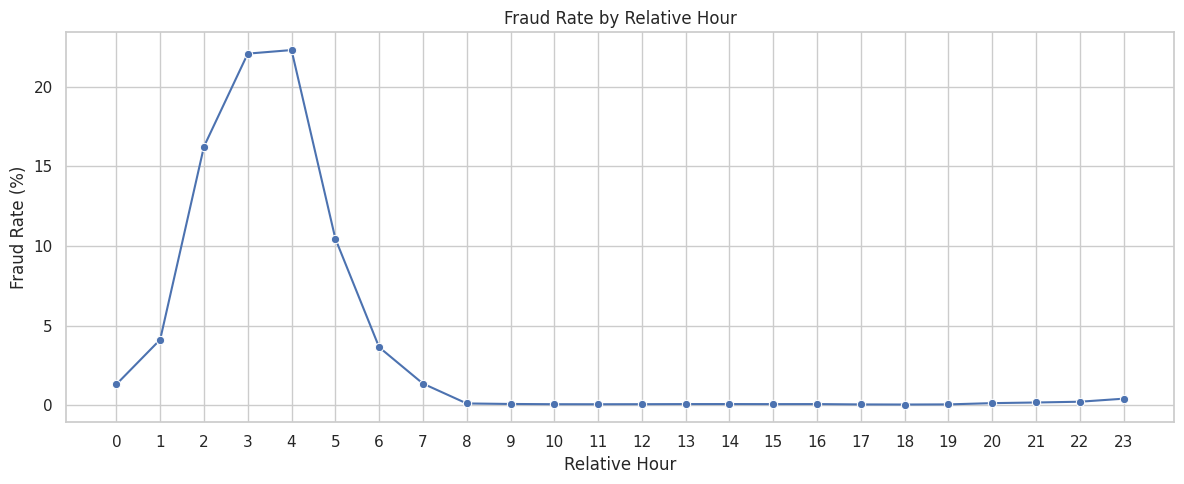

In [ ]:
plt.figure(figsize=(12,5))

sns.lineplot(data=hourly_fraud.reset_index(), x="RELATIVE_HOUR", y="Fraud_Rate", marker="o")
plt.title("Fraud Rate by Relative Hour")
plt.xlabel("Relative Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

## Part 23: Fraud Over Simulation Time

In [ ]:
daily_fraud = paysim.groupby("RELATIVE_DAY")["isFraud"].agg(
    Transactions="size",
    Fraud_Count="sum",
    Fraud_Rate="mean"
)
daily_fraud["Fraud_Rate"] *= 100

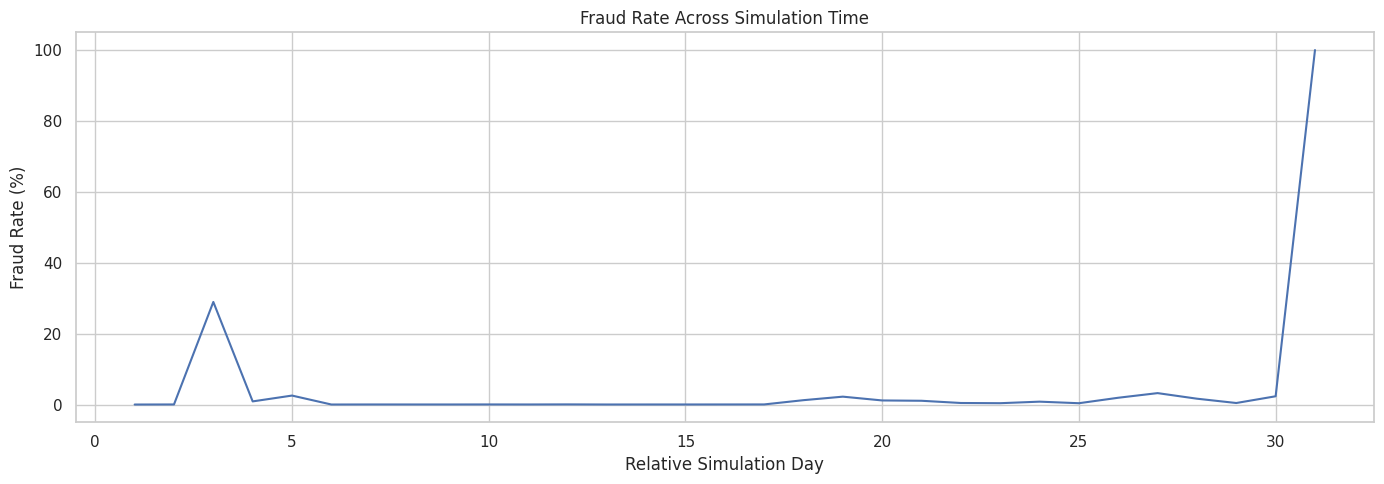

In [ ]:
plt.figure(figsize=(14,5))

sns.lineplot(data=daily_fraud.reset_index(), x="RELATIVE_DAY", y="Fraud_Rate")
plt.title("Fraud Rate Across Simulation Time")
plt.xlabel("Relative Simulation Day")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

## Part 24: Balance Behaviour

In [ ]:
print("\n" + "="*80)
print("PART 10: BALANCE BEHAVIOUR ANALYSIS")
print("="*80)

paysim["ORIG_BALANCE_ERROR"] = (paysim["oldbalanceOrg"] - paysim["amount"] - paysim["newbalanceOrig"]).abs()
paysim["DEST_BALANCE_ERROR"] = (paysim["oldbalanceDest"] + paysim["amount"] - paysim["newbalanceDest"]).abs()


PART 10: BALANCE BEHAVIOUR ANALYSIS


## Part 25: Balance Error by Fraud Status

In [ ]:
balance_features = ["ORIG_BALANCE_ERROR", "DEST_BALANCE_ERROR"]

display(paysim.groupby("isFraud")[balance_features].median().T)

isFraud,0,1
ORIG_BALANCE_ERROR,69049.312500,0.00000
DEST_BALANCE_ERROR,5123.109863,9511.69043


In [ ]:
display(paysim.groupby("isFraud")[balance_features].mean().T)

isFraud,0,1
ORIG_BALANCE_ERROR,201338.546875,10692.331055
DEST_BALANCE_ERROR,92756.976562,745138.625000


## Part 26: Origin Balance Error Distribution

In [ ]:
paysim["LOG_ORIG_BALANCE_ERROR"] = np.log1p(paysim["ORIG_BALANCE_ERROR"])

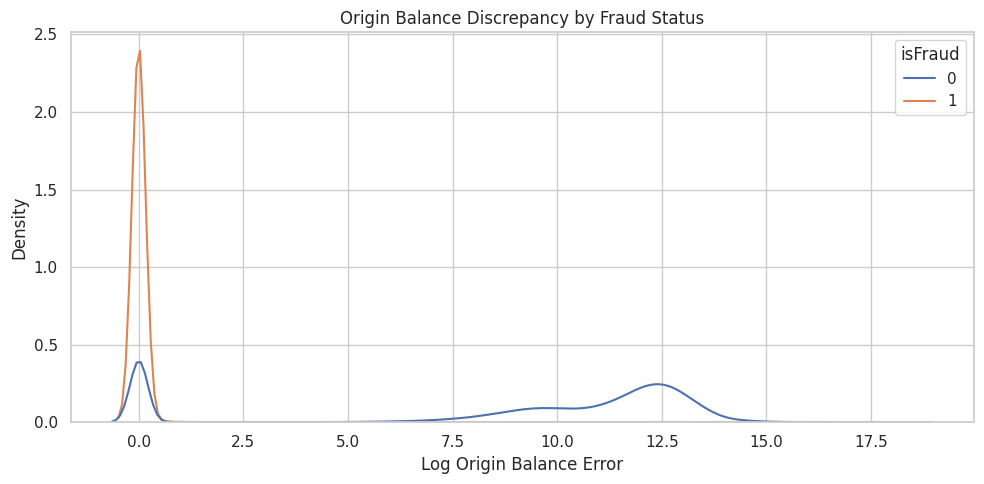

In [ ]:
plt.figure(figsize=(10,5))

sns.kdeplot(data=paysim, x="LOG_ORIG_BALANCE_ERROR", hue="isFraud", common_norm=False)
plt.title("Origin Balance Discrepancy by Fraud Status")
plt.xlabel("Log Origin Balance Error")
plt.tight_layout()
plt.show()

## Part 27: Amount Relative to Origin Balance

In [ ]:
paysim["AMOUNT_ORIG_BALANCE_RATIO"] = paysim["amount"] / paysim["oldbalanceOrg"].replace(0, np.nan)

In [ ]:
ratio_plot = paysim[["AMOUNT_ORIG_BALANCE_RATIO", "isFraud"]].dropna().copy()
ratio_plot["AMOUNT_ORIG_BALANCE_RATIO"] = ratio_plot["AMOUNT_ORIG_BALANCE_RATIO"].clip(upper=5)

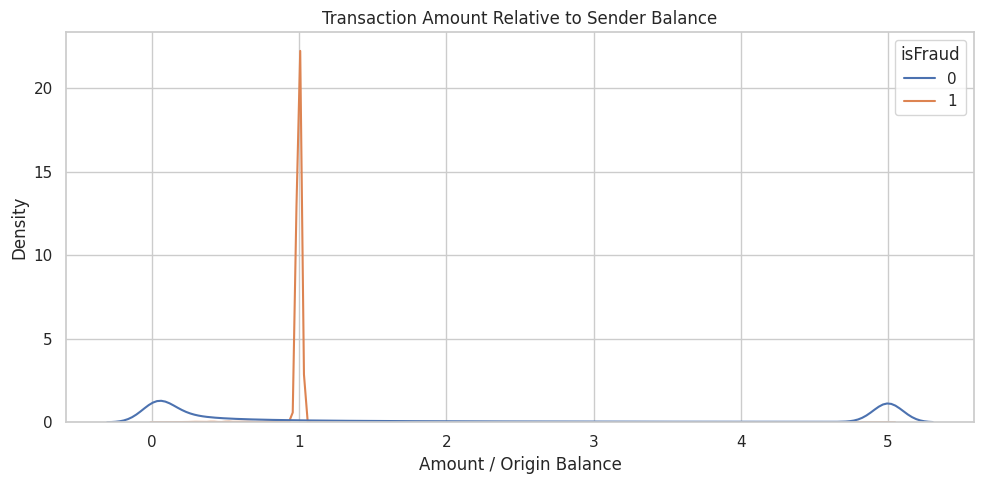

7611

In [ ]:
plt.figure(figsize=(10,5))

sns.kdeplot(data=ratio_plot, x="AMOUNT_ORIG_BALANCE_RATIO", hue="isFraud", common_norm=False)
plt.title("Transaction Amount Relative to Sender Balance")
plt.xlabel("Amount / Origin Balance")
plt.tight_layout()
plt.show()

del ratio_plot
gc.collect()

## Part 28: Does Transaction Empty the Origin Account?

In [ ]:
paysim["ORIGIN_EMPTIED"] = ((paysim["oldbalanceOrg"] > 0) & (paysim["newbalanceOrig"] == 0)).astype("uint8")

In [ ]:
origin_empty_risk = paysim.groupby("ORIGIN_EMPTIED")["isFraud"].agg(
    Transactions="size",
    Fraud_Count="sum",
    Fraud_Rate="mean"
)
origin_empty_risk["Fraud_Rate"] *= 100

display(origin_empty_risk)

,Transactions,Fraud_Count,Fraud_Rate
ORIGIN_EMPTIED,,,
0,4842039,201,0.004151
1,1520581,8012,0.526904


## Part 29: Is Amount Approximately Equal to Origin Balance?

In [ ]:
paysim["FULL_BALANCE_TRANSFER"] = np.isclose(paysim["amount"], paysim["oldbalanceOrg"], rtol=0.001, atol=1).astype("uint8")

In [ ]:
full_balance_risk = paysim.groupby("FULL_BALANCE_TRANSFER")["isFraud"].agg(
    Transactions="size",
    Fraud_Count="sum",
    Fraud_Rate="mean"
)
full_balance_risk["Fraud_Rate"] *= 100

display(full_balance_risk)

,Transactions,Fraud_Count,Fraud_Rate
FULL_BALANCE_TRANSFER,,,
0,6353572,179,0.002817
1,9048,8034,88.793103


## Part 30: Zero Balance Behaviour

In [ ]:
paysim["ZERO_ORIGIN_BEFORE"] = (paysim["oldbalanceOrg"] == 0).astype("uint8")
paysim["ZERO_ORIGIN_AFTER"] = (paysim["newbalanceOrig"] == 0).astype("uint8")
paysim["ZERO_DEST_BEFORE"] = (paysim["oldbalanceDest"] == 0).astype("uint8")
paysim["ZERO_DEST_AFTER"] = (paysim["newbalanceDest"] == 0).astype("uint8")

In [ ]:
zero_features = ["ZERO_ORIGIN_BEFORE", "ZERO_ORIGIN_AFTER", "ZERO_DEST_BEFORE", "ZERO_DEST_AFTER"]

for col in zero_features:
    result = paysim.groupby(col)["isFraud"].agg(
        Transactions="size",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
    result["Fraud_Rate"] *= 100
    print(f"\n{col}")
    display(result)


ZERO_ORIGIN_BEFORE


,Transactions,Fraud_Count,Fraud_Rate
ZERO_ORIGIN_BEFORE,,,
0,4260171,8172,0.191823
1,2102449,41,0.001950



ZERO_ORIGIN_AFTER


,Transactions,Fraud_Count,Fraud_Rate
ZERO_ORIGIN_AFTER,,,
0,2753054,160,0.005812
1,3609566,8053,0.223102



ZERO_DEST_BEFORE


,Transactions,Fraud_Count,Fraud_Rate
ZERO_DEST_BEFORE,,,
0,3658232,2862,0.078235
1,2704388,5351,0.197864



ZERO_DEST_AFTER


,Transactions,Fraud_Count,Fraud_Rate
ZERO_DEST_AFTER,,,
0,3923187,4122,0.105068
1,2439433,4091,0.167703


## Part 31: Origin Account Transaction Frequency

In [ ]:
print("\n" + "="*80)
print("PART 11: ACCOUNT BEHAVIOUR ANALYSIS")
print("="*80)

paysim["ORIG_TRANSACTION_COUNT"] = paysim.groupby("nameOrig")["nameOrig"].transform("size").astype("int16")


PART 11: ACCOUNT BEHAVIOUR ANALYSIS


In [ ]:
paysim["DEST_TRANSACTION_COUNT"] = paysim.groupby("nameDest")["nameDest"].transform("size")
paysim["DEST_TRANSACTION_COUNT"] = paysim["DEST_TRANSACTION_COUNT"].astype("int32")

In [ ]:
display(paysim.groupby("isFraud")[["ORIG_TRANSACTION_COUNT", "DEST_TRANSACTION_COUNT"]].median().T)

isFraud,0,1
ORIG_TRANSACTION_COUNT,1.0,1.0
DEST_TRANSACTION_COUNT,7.0,4.0


## Part 32: Destination Account Type

In [ ]:
paysim["DEST_PREFIX"] = paysim["nameDest"].str[0].astype("category")

In [ ]:
dest_prefix_risk = paysim.groupby("DEST_PREFIX", observed=False)["isFraud"].agg(
    Transactions="size",
    Fraud_Count="sum",
    Fraud_Rate="mean"
)
dest_prefix_risk["Fraud_Rate"] *= 100

display(dest_prefix_risk)

,Transactions,Fraud_Count,Fraud_Rate
DEST_PREFIX,,,
C,4211125,8213,0.195031
M,2151495,0,0.000000


## Part 33: Correlation with Fraud

In [ ]:
print("\n" + "="*80)
print("PART 12: FEATURE ASSOCIATION ANALYSIS")
print("="*80)

association_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "ORIG_BALANCE_ERROR",
    "DEST_BALANCE_ERROR",
    "AMOUNT_ORIG_BALANCE_RATIO",
    "ORIGIN_EMPTIED",
    "FULL_BALANCE_TRANSFER",
    "ZERO_ORIGIN_BEFORE",
    "ZERO_ORIGIN_AFTER",
    "ZERO_DEST_BEFORE",
    "ZERO_DEST_AFTER",
    "ORIG_TRANSACTION_COUNT",
    "DEST_TRANSACTION_COUNT"
]


PART 12: FEATURE ASSOCIATION ANALYSIS


In [ ]:
corr_results = []

for col in association_features:
    temp_corr = paysim[col].corr(paysim["isFraud"])
    corr_results.append({
        "Feature": col,
        "Correlation": temp_corr,
        "Absolute_Correlation": abs(temp_corr)
    })

correlation_df = pd.DataFrame(corr_results).sort_values("Absolute_Correlation", ascending=False)

display(correlation_df)

,Feature,Correlation,Absolute_Correlation
10,FULL_BALANCE_TRANSFER,0.931885,0.931885
1,amount,0.076688,0.076688
9,ORIGIN_EMPTIED,0.062091,0.062091
7,DEST_BALANCE_ERROR,0.053840,0.053840
0,step,0.031578,0.031578
12,ZERO_ORIGIN_AFTER,0.029984,0.029984
11,ZERO_ORIGIN_BEFORE,-0.024874,0.024874
13,ZERO_DEST_BEFORE,0.016471,0.016471
6,ORIG_BALANCE_ERROR,-0.011283,0.011283
2,oldbalanceOrg,0.010154,0.010154


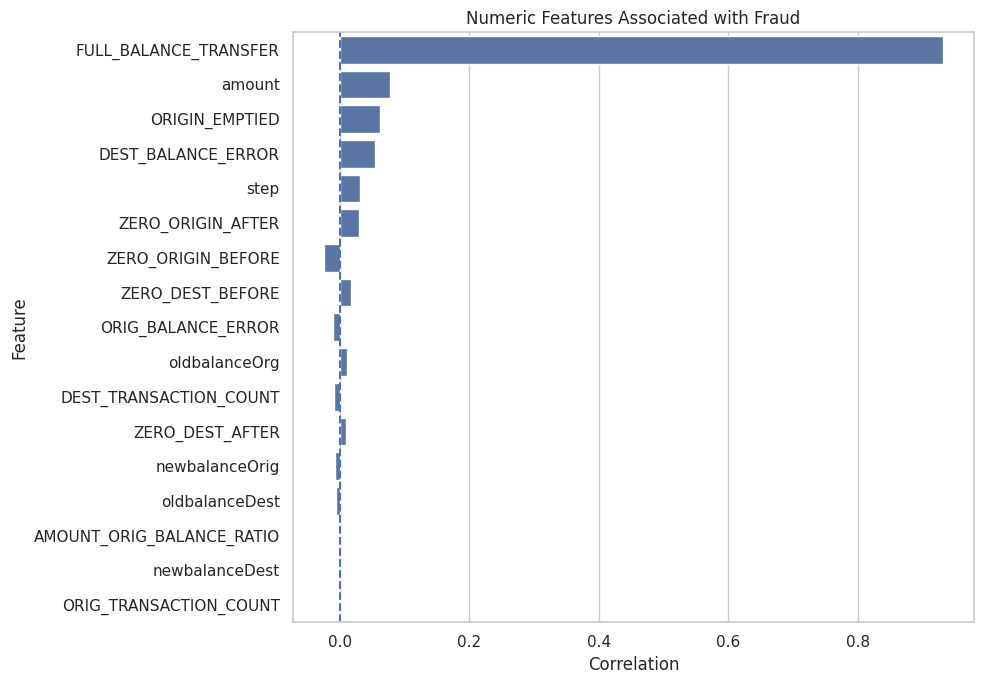

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(data=correlation_df, x="Correlation", y="Feature")
plt.axvline(0, linestyle="--")
plt.title("Numeric Features Associated with Fraud")
plt.tight_layout()
plt.show()

## Part 34: Univariate AUC Ranking

In [ ]:
print("\n13.1 Univariate AUC Analysis")

auc_results = []
target = paysim["isFraud"].to_numpy()

for col in association_features:
    x = paysim[col].to_numpy(copy=False)
    valid = np.isfinite(x)

    if valid.sum() < 100:
        continue

    x_valid = x[valid]
    y_valid = target[valid]

    if np.unique(x_valid).size < 2:
        continue

    try:
        auc = roc_auc_score(y_valid, x_valid)
        auc_results.append({
            "Feature": col,
            "Raw_AUC": auc,
            "Predictive_AUC": max(auc, 1 - auc)
        })
    except:
        continue


13.1 Univariate AUC Analysis


In [ ]:
auc_df = pd.DataFrame(auc_results).sort_values("Predictive_AUC", ascending=False)
display(auc_df)

,Feature,Raw_AUC,Predictive_AUC
10,FULL_BALANCE_TRANSFER,0.989023,0.989023
6,ORIG_BALANCE_ERROR,0.081840,0.918160
9,ORIGIN_EMPTIED,0.868746,0.868746
2,oldbalanceOrg,0.811247,0.811247
1,amount,0.789921,0.789921
12,ZERO_ORIGIN_AFTER,0.706872,0.706872
3,newbalanceOrig,0.296240,0.703760
0,step,0.667382,0.667382
11,ZERO_ORIGIN_BEFORE,0.337067,0.662933
4,oldbalanceDest,0.367582,0.632418


## Part 35: AUC Plot

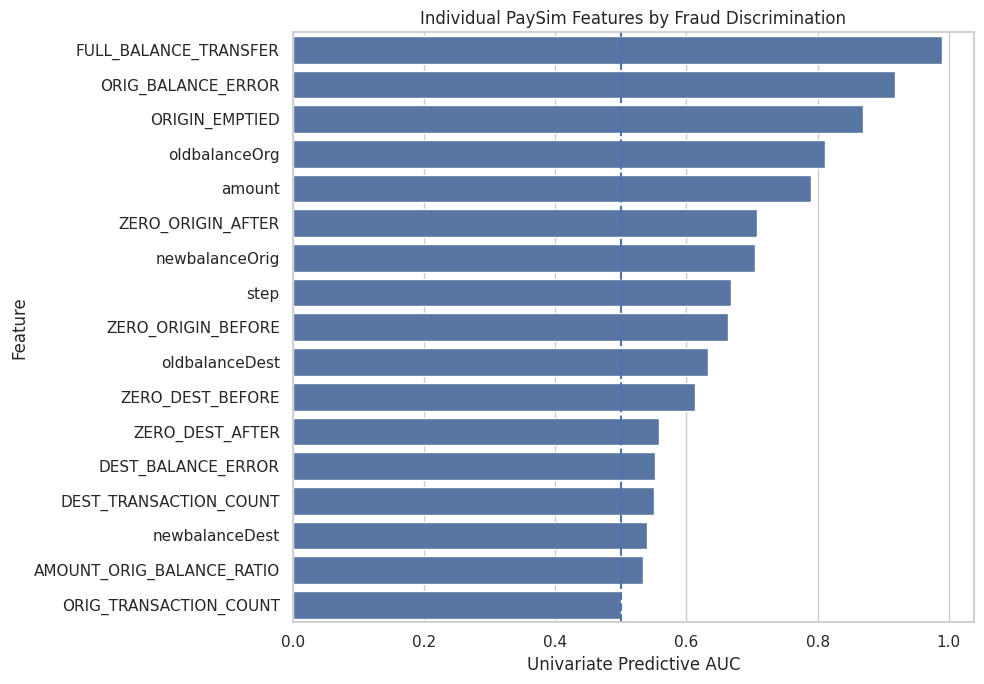

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(data=auc_df, x="Predictive_AUC", y="Feature")
plt.axvline(0.5, linestyle="--")
plt.title("Individual PaySim Features by Fraud Discrimination")
plt.xlabel("Univariate Predictive AUC")
plt.tight_layout()
plt.show()

## Part 36: Transaction Type Association Test

In [ ]:
contingency_table = pd.crosstab(paysim["type"], paysim["isFraud"])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.10f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 22082.5357
P-value: 0.0000000000
Degrees of freedom: 4


## Part 37: Interaction: Transaction Type x Amount

In [ ]:
paysim["AMOUNT_GROUP"] = pd.qcut(paysim["amount"], q=5, duplicates="drop")

In [ ]:
type_amount_interaction = paysim.groupby(["type", "AMOUNT_GROUP"], observed=False)["isFraud"].mean().unstack()

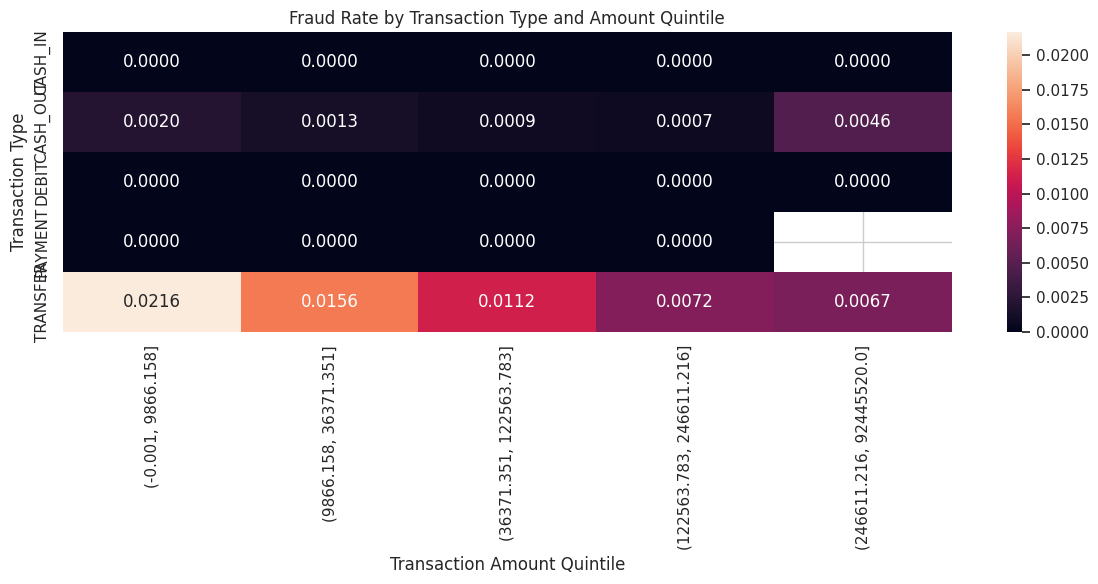

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(type_amount_interaction, annot=True, fmt=".4f")
plt.title("Fraud Rate by Transaction Type and Amount Quintile")
plt.xlabel("Transaction Amount Quintile")
plt.ylabel("Transaction Type")
plt.tight_layout()
plt.show()

## Part 38: Interaction: Type x Origin Emptied

In [ ]:
type_empty_interaction = paysim.groupby(["type", "ORIGIN_EMPTIED"], observed=False)["isFraud"].mean().unstack()

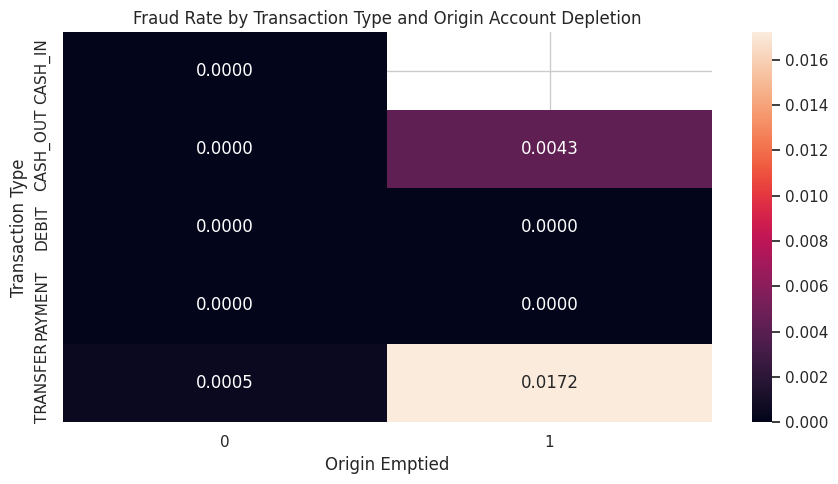

In [ ]:
plt.figure(figsize=(9,5))

sns.heatmap(type_empty_interaction, annot=True, fmt=".4f")
plt.title("Fraud Rate by Transaction Type and Origin Account Depletion")
plt.xlabel("Origin Emptied")
plt.ylabel("Transaction Type")
plt.tight_layout()
plt.show()

## Part 39: Existing Flag by Transaction Type

In [ ]:
flag_type = paysim.groupby("type", observed=False)[["isFraud", "isFlaggedFraud"]].sum()
flag_type["Frauds_Missed"] = flag_type["isFraud"] - flag_type["isFlaggedFraud"]

display(flag_type)

,isFraud,isFlaggedFraud,Frauds_Missed
type,,,
CASH_IN,0,0,0
CASH_OUT,4116,0,4116
DEBIT,0,0,0
PAYMENT,0,0,0
TRANSFER,4097,16,4081


## Part 40: Static High-Amount Rule

In [ ]:
amount_95 = paysim["amount"].quantile(0.95)
print(f"95th percentile transaction amount: {amount_95:,.2f}")

95th percentile transaction amount: 518,634.19


In [ ]:
paysim["HIGH_AMOUNT_FLAG"] = (paysim["amount"] >= amount_95).astype("uint8")

In [ ]:
cm_amount = confusion_matrix(paysim["isFraud"], paysim["HIGH_AMOUNT_FLAG"])
tn_a, fp_a, fn_a, tp_a = cm_amount.ravel()

precision_a = tp_a / (tp_a + fp_a) if tp_a + fp_a > 0 else 0
recall_a = tp_a / (tp_a + fn_a) if tp_a + fn_a > 0 else 0
fpr_a = fp_a / (fp_a + tn_a) if fp_a + tn_a > 0 else 0

print("High-Amount Rule Performance")
print("="*50)
print(f"Precision: {precision_a:.4f}")
print(f"Recall: {recall_a:.4f}")
print(f"False Positive Rate: {fpr_a:.6f}")
print(f"False Positives: {fp_a:,}")
print(f"Frauds Detected: {tp_a:,}")

High-Amount Rule Performance
Precision: 0.0120
Recall: 0.4630
False Positive Rate: 0.049466
False Positives: 314,328
Frauds Detected: 3,803


## Part 41: Compare the Two Rule-Based Systems

In [ ]:
baseline_comparison = pd.DataFrame({
    "Baseline": ["PaySim Existing Flag", "95th Percentile Amount Rule"],
    "Precision": [precision, precision_a],
    "Recall": [recall, recall_a],
    "F1": [f1, f1_score(paysim["isFraud"], paysim["HIGH_AMOUNT_FLAG"], zero_division=0)],
    "False Positive Rate": [false_positive_rate, fpr_a]
})

display(baseline_comparison)

,Baseline,Precision,Recall,F1,False Positive Rate
0,PaySim Existing Flag,1.000000,0.001948,0.003889,0.000000
1,95th Percentile Amount Rule,0.011954,0.463046,0.023307,0.049466


## Part 42: Final EDA Summary

In [ ]:
print("\n" + "="*80)
print("PART 14: EDA SUMMARY")
print("="*80)

print(f"\nTotal transactions: {len(paysim):,}")
print(f"Total variables before feature engineering: 11")
print(f"Fraudulent transactions: {fraud_count:,}")
print(f"Overall fraud rate: {paysim['isFraud'].mean()*100:.4f}%")
print(f"Fraud transaction value share: {fraud_value_share:.4f}%")


PART 14: EDA SUMMARY

Total transactions: 6,362,620
Total variables before feature engineering: 11
Fraudulent transactions: 8,213
Overall fraud rate: 0.1291%
Fraud transaction value share: 1.0535%


In [ ]:
print("\nFraud rates by transaction type:")
display(fraud_by_type)


Fraud rates by transaction type:


,Transactions,Fraud_Count,Fraud_Rate
type,,,
TRANSFER,532909,4097,0.768799
CASH_OUT,2237500,4116,0.183955
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


In [ ]:
print("\nTop candidate numeric fraud indicators:")
display(auc_df.head(10))


Top candidate numeric fraud indicators:


,Feature,Raw_AUC,Predictive_AUC
10,FULL_BALANCE_TRANSFER,0.989023,0.989023
6,ORIG_BALANCE_ERROR,0.081840,0.918160
9,ORIGIN_EMPTIED,0.868746,0.868746
2,oldbalanceOrg,0.811247,0.811247
1,amount,0.789921,0.789921
12,ZERO_ORIGIN_AFTER,0.706872,0.706872
3,newbalanceOrig,0.296240,0.703760
0,step,0.667382,0.667382
11,ZERO_ORIGIN_BEFORE,0.337067,0.662933
4,oldbalanceDest,0.367582,0.632418


In [ ]:
print("\nRule-based baseline performance:")
display(baseline_comparison)


Rule-based baseline performance:


,Baseline,Precision,Recall,F1,False Positive Rate
0,PaySim Existing Flag,1.000000,0.001948,0.003889,0.000000
1,95th Percentile Amount Rule,0.011954,0.463046,0.023307,0.049466


## Part 43: Save EDA Results

In [ ]:
fraud_by_type.to_csv(BASE_PATH / "paysim_fraud_by_transaction_type.csv")
amount_risk.to_csv(BASE_PATH / "paysim_fraud_by_amount.csv")
correlation_df.to_csv(BASE_PATH / "paysim_feature_correlations.csv", index=False)
auc_df.to_csv(BASE_PATH / "paysim_univariate_auc.csv", index=False)
baseline_comparison.to_csv(BASE_PATH / "paysim_rule_baseline.csv", index=False)

print("PaySim EDA results saved successfully!")

PaySim EDA results saved successfully!


In [ ]:
print("\nEDA Complete!")
print("="*60)


EDA Complete!
